In [12]:
import DTRGym
import gymnasium as gym
import numpy as np
import os
import sys
import pickle as pkl
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import torch
import matplotlib.pyplot as plt
import argparse
import csv
from gymnasium.core import RewardWrapper
from scipy import stats
from flow_matching.solver import ODESolver
from torch import nn, Tensor
from flow_matching.utils import ModelWrapper
import pandas as pd

In [8]:
sys.path.append('../NLOT')
AGENT_PATH = "policies/ppo_ghaffari_cancer_model__0.zip"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'GhaffariCancerEnv-continuous'
NUM_EVAL_EPISODES = 10
LAMBDA_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
device = "cuda:0"

In [3]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [40]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [4]:
class CustomRewardWrapper(RewardWrapper):
    def __init__(self, env, lambda_nk: float = 0.5):
        super().__init__(env)
        self.lambda_nk = lambda_nk
        self.init_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.init_obs = np.array(obs, copy=True)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        if self.init_obs is not None:
            N_p  = obs[1]
            N_s  = obs[5]
            N_p0 = self.init_obs[1]
            N_s0 = self.init_obs[5]
            N  = max(np.e,  N_p  + N_s)
            N0 = max(np.e,  N_p0 + N_s0)
            logN, logN0 = np.log(N), np.log(N0)
            nk_penalty = -np.abs(logN / logN0 - 1)
            reward = reward + self.lambda_nk * nk_penalty

        return obs, reward, terminated, truncated, info

In [5]:
def flow_forward(action, obs, lambda_val, cfm_models):
    """
    Uses the trained CFM model to push actions forward to target lambda.

    cfm_models is a dict, with key as the time of the end point, and value as the CFM model.
    """
    time_points = list(cfm_models.keys())
    current_action = action.copy()
    t_low = 0
    step_size = 0.01

    if lambda_val <= 0:
        return action

    for k in range(len(time_points)):
        t_high = time_points[k]

        if t_low <= lambda_val <= t_high:
            cfm_model = list(cfm_models.values())[k]
            lambda_val_scaled = (lambda_val - t_low) / (t_high - t_low)
            solver = ODESolver(velocity_model=cfm_model)

            current_action = solver.sample(
                time_grid=torch.tensor([0, lambda_val_scaled], device='cuda:0'), 
                x_init=torch.tensor([current_action], device='cuda:0'), 
                cond=torch.tensor([obs], device='cuda:0'), 
                method='midpoint', 
                step_size=step_size, 
                return_intermediates=True
                )[-1]
            
            break
        cfm_model = list(cfm_models.values())[k]
        solver = ODESolver(velocity_model=cfm_model)

        current_action = solver.sample(
            time_grid=torch.tensor([0, 1.0], device='cuda:0'),
            x_init=torch.tensor([current_action], device='cuda:0'), 
            cond=torch.tensor([obs], device='cuda:0'), 
            method='midpoint', 
            step_size=step_size, 
            return_intermediates=True
            )[-1].cpu().numpy()

        t_low = t_high

    action_dim = action.shape[1] if len(action.shape) > 1 else action.shape[0]
    flowforward_action = current_action[:action_dim].reshape(action.shape)
    flowforward_action = np.array(flowforward_action.cpu(), dtype=np.float32)
    return flowforward_action

In [6]:
def calculate_nk_penalty(current_obs_vec, initial_obs_vec):
    current_obs = current_obs_vec[0]
    initial_obs = initial_obs_vec[0]

    N_p  = current_obs[1]
    N_s  = current_obs[5]
    N_p0 = initial_obs[1]
    N_s0 = initial_obs[5]

    N  = max(np.e,  N_p  + N_s)
    N0 = max(np.e,  N_p0 + N_s0)

    logN = np.log(N)
    logN0 = np.log(N0)

    penalty = -np.abs(logN / logN0 - 1)
    return penalty


In [7]:
def evaluate_lambda(model, lambda_val, workspace):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    print(f'\n--- Evaluating agent {AGENT_NAME} for NK penalty with lambda = {lambda_val} ---')

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = flow_forward(action, obs, lambda_val, workspace)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    print(f"\n--- Summary for Lambda = {lambda_val} ---")
    print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [47]:
#load flow matching models
flow_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=128).to(device) 
wrapped_flow_0 = WrappedModel(flow_0)
flow_0_weights = torch.load('../rebuttal_baselines/wrapped_vf_0_rl.pt')
wrapped_flow_0.load_state_dict(flow_0_weights)

flow_1 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=128).to(device)
wrapped_flow_1 = WrappedModel(flow_1)
flow_1_weights = torch.load('../rebuttal_baselines/wrapped_vf_1_rl.pt')
wrapped_flow_1.load_state_dict(flow_1_weights)

flow_models={0.5: wrapped_flow_0, 1.0: wrapped_flow_1}

In [48]:
model = PPO.load(AGENT_PATH)

In [49]:
pens = []
rewards = []
for lambda_val in LAMBDA_VALUES:
    print(f"Evaluating lambda value: {lambda_val}")
    eval = evaluate_lambda(model, lambda_val, flow_models)
    pens.append(eval[0])
    rewards.append(eval[2])

Evaluating lambda value: 0.0

--- Evaluating agent single_agent_eval for NK penalty with lambda = 0.0 ---
Starting Episode 1/10
Episode 1: Average NK Penalty = -0.0659, Steps = 41
Starting Episode 2/10


Episode 2: Average NK Penalty = -0.0658, Steps = 41
Starting Episode 3/10
Episode 3: Average NK Penalty = -0.0636, Steps = 41
Starting Episode 4/10
Episode 4: Average NK Penalty = -0.0662, Steps = 41
Starting Episode 5/10
Episode 5: Average NK Penalty = -0.0664, Steps = 43
Starting Episode 6/10
Episode 6: Average NK Penalty = -0.0666, Steps = 42
Starting Episode 7/10
Episode 7: Average NK Penalty = -0.0657, Steps = 42
Starting Episode 8/10
Episode 8: Average NK Penalty = -0.0642, Steps = 43
Starting Episode 9/10
Episode 9: Average NK Penalty = -0.0657, Steps = 41
Starting Episode 10/10
Episode 10: Average NK Penalty = -0.0657, Steps = 43

--- Summary for Lambda = 0.0 ---
Overall Average NK Penalty across 10 episodes = -0.0656
Standard Deviation of Per-Episode Average NK Penalties = 0.0009
Overall Average Reward across 10 episodes = 99.6345
Evaluating lambda value: 0.1

--- Evaluating agent single_agent_eval for NK penalty with lambda = 0.1 ---
Starting Episode 1/10
Episode 1: Average N

In [50]:
np.mean(rewards)

30.596463888341734

In [13]:
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')

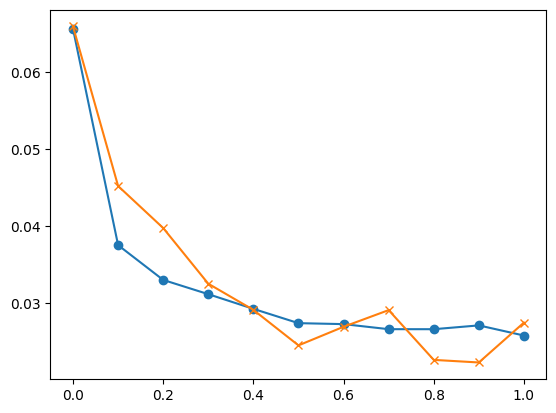

In [51]:
plt.plot(LAMBDA_VALUES, [-i for i in pens], marker='o')
plt.plot(LAMBDA_VALUES, [-i for i in true['Average Penalty']], marker='x')

In [ ]:
if LAMBDA_VALUES:
    combined_results = {}
    for lambda_val in LAMBDA_VALUES:
        combined_results[lambda_val] = {
            'penalties': [],
            'rewards': []
        }

    for workspace_file in workspace_files:
        workspace_path = os.path.join(WORKSPACES_DIR, workspace_file)
        workspace_name = os.path.splitext(os.path.basename(workspace_path))[0]
        print(f"\n===== Processing Workspace: {workspace_name} =====")
        
        workspace = load_workspace(workspace_path)
        if workspace is None:
            print(f"Could not load workspace from {workspace_path}, skipping...")
            continue
            
        lambda_results = []
        all_lambda_rewards = [] 
        
        for lambda_val in LAMBDA_VALUES:
            avg_penalty, std_dev, avg_reward = evaluate_lambda(model, lambda_val, workspace)
            lambda_results.append((lambda_val, avg_penalty, std_dev))
            all_lambda_rewards.append(avg_reward)
            
            combined_results[lambda_val]['penalties'].append(avg_penalty)
            combined_results[lambda_val]['rewards'].append(avg_reward)
        
        overall_avg_reward = np.mean(all_lambda_rewards)
        print(f"Average Reward across all lambda values for {workspace_name} = {overall_avg_reward:.4f}")
        all_workspace_results[workspace_name] = overall_avg_reward
        
        plot_lambdas = [item[0] for item in lambda_results]
        plot_avg_penalties = [item[1] for item in lambda_results]
        plot_std_devs = [item[2] for item in lambda_results]

        plt.figure(figsize=(10, 6))
        plt.errorbar(plot_lambdas, plot_avg_penalties, yerr=plot_std_devs, marker='o', linestyle='-', capsize=5)
        plt.title(f"{workspace_name}: Overall Average NK Penalty vs. Lambda Value ({NUM_EVAL_EPISODES} Episodes)")
        plt.xlabel("Lambda Value")
        plt.ylabel("Overall Average NK Penalty")
        plt.grid(True)
        plt.xticks(plot_lambdas)
        plt.tight_layout()
        plot_filename = os.path.join(PLOT_DIR, f"surrogate_avg_nk_penalty_vs_lambda_{RUN_NAME}_{workspace_name}.png")
        plt.savefig(plot_filename)
        plt.close()
        
        csv_filename = os.path.join(PLOT_DIR, f"surrogate_nk_penalty_data_{RUN_NAME}_{workspace_name}.csv")
        with open(csv_filename, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Lambda', 'Average Penalty', 'Standard Deviation', 'Average Reward'])
            for i, row in enumerate(lambda_results):
                writer.writerow(list(row) + [all_lambda_rewards[i]])
        print(f"Saved data for {workspace_name} to {csv_filename}")
    
    avg_penalties = []
    std_penalties = []
    avg_rewards = []
    
    for lambda_val in LAMBDA_VALUES:
        penalties = combined_results[lambda_val]['penalties']
        rewards = combined_results[lambda_val]['rewards']
        if penalties:
            avg_penalties.append(np.mean(penalties))
            std_penalties.append(np.std(penalties))
            avg_rewards.append(np.mean(rewards))
        else:
            avg_penalties.append(0)
            std_penalties.append(0)
            avg_rewards.append(0)
    
    plt.figure(figsize=(10, 6))
    plt.errorbar(LAMBDA_VALUES, avg_penalties, yerr=std_penalties, marker='o', linestyle='-', capsize=5)
    plt.title(f"Average NK Penalty vs. Lambda Value (Across All Workspaces)")
    plt.xlabel("Lambda Value")
    plt.ylabel("Average NK Penalty")
    plt.grid(True)
    plt.xticks(LAMBDA_VALUES)
    plt.tight_layout()
    avg_plot_filename = os.path.join(PLOT_DIR, f"surrogate_avg_nk_penalty_vs_lambda_all_{RUN_NAME}_{ITER}.png")
    plt.savefig(avg_plot_filename)
    print(f"\nSaved average plot across all workspaces to {avg_plot_filename}")
    plt.close()
    
    plt.figure(figsize=(10, 6))
    plt.plot(LAMBDA_VALUES, avg_rewards, marker='o', linestyle='-')
    plt.title(f"Average Reward vs. Lambda Value (Across All Workspaces)")
    plt.xlabel("Lambda Value")
    plt.ylabel("Average Reward")
    plt.grid(True)
    plt.xticks(LAMBDA_VALUES)
    plt.tight_layout()
    reward_plot_filename = os.path.join(PLOT_DIR, f"surrogate_avg_reward_vs_lambda_all_{RUN_NAME}_{ITER}.png")
    plt.savefig(reward_plot_filename)
    print(f"Saved average reward plot across all workspaces to {reward_plot_filename}")
    plt.close()
    
    combined_csv = os.path.join(PLOT_DIR, f"surrogate_results_{RUN_NAME}_{ITER}.csv")
    with open(combined_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Lambda', 'Average Penalty', 'Penalty StdDev', 'Average Reward'])
        for i, lambda_val in enumerate(LAMBDA_VALUES):
            writer.writerow([lambda_val, avg_penalties[i], std_penalties[i], avg_rewards[i]])
    print(f"Saved combined data to {combined_csv}")

    valid_rewards = [r for r in all_workspace_results.values() if r is not None]
    overall_reward = np.mean(valid_rewards)
    n = len(valid_rewards)
    if n > 1:
        reward_std = np.std(valid_rewards)
        reward_se = reward_std / np.sqrt(n)
        t_value = stats.t.ppf(0.975, n-1)
        reward_ci = t_value * reward_se
        
        print(f"\n===== Overall Results =====")
        print(f"Average Reward across all lambda values and all workspaces = {overall_reward:.4f}")
        print(f"95% CI for Final Average: [{overall_reward - reward_ci:.4f}, {overall_reward + reward_ci:.4f}]")
    else:
        print(f"\n===== Overall Results =====")
        print(f"Average Reward across all lambda values and all workspaces = {overall_reward:.4f}")
        print("(Not enough samples to calculate confidence interval)")
    
    final_results_file = os.path.join(PLOT_DIR, f"final_avg_reward_{RUN_NAME}_{ITER}.txt")
    with open(final_results_file, 'w') as f:
        f.write(f"===== Overall Results =====\n")
        f.write(f"Average Reward across all lambda values and all workspaces = {overall_reward:.4f}\n")
        if n > 1:
            f.write(f"95% CI for Final Average: [{overall_reward - reward_ci:.4f}, {overall_reward + reward_ci:.4f}]\n")
        else:
            f.write("(Not enough samples to calculate confidence interval)\n")
    print(f"Saved final average reward to {final_results_file}")
    print("\n===== Workspace Comparison =====")
    for workspace_name, avg_reward in all_workspace_results.items():
        print(f"{workspace_name}: Average Reward = {avg_reward:.4f}")
    
else:
    for workspace_file in workspace_files:
        workspace_path = os.path.join(WORKSPACES_DIR, workspace_file)
        workspace_name = os.path.splitext(os.path.basename(workspace_path))[0]
        print(f"\n===== Processing Workspace: {workspace_name} with Lambda = {LAMBDA_PUSHFORWARD} =====")
        
        workspace = load_workspace(workspace_path)
        if workspace is None:
            print(f"Could not load workspace from {workspace_path}, skipping...")
            continue
            
        avg_penalty, std_dev, avg_reward = evaluate_single_lambda(model, LAMBDA_PUSHFORWARD, workspace)
        all_workspace_results[workspace_name] = avg_reward
    
    print("\n===== Workspace Comparison =====")
    valid_rewards = []
    for workspace_name, avg_reward in all_workspace_results.items():
        if avg_reward is not None:
            print(f"{workspace_name}: Average Reward = {avg_reward:.4f}")
            valid_rewards.append(avg_reward)
        else:
            print(f"{workspace_name}: Evaluation failed")
    
    if valid_rewards:
        overall_avg = np.mean(valid_rewards)
        print(f"\nAverage reward across all workspaces = {overall_avg:.4f}")

print("\nEvaluation complete.")

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/wandb/apis/public.py:3106: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/pkg_resources/__init__.py:3147: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/pkg_resources/__init__.py:3147: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('lazr')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/la

ModuleNotFoundError: No module named 'jax'